In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import zipfile

zip_path = "/content/archive (2).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [5]:
import os
os.listdir("/content")

['.config', 'data.csv', 'archive (2).zip', 'sample_data']

In [8]:
import pandas as pd

data = pd.read_csv("/content/data.csv", encoding="latin1")
data.head()

/tmp/ipython-input-184575739.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/content/data.csv", encoding="latin1")


,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


In [13]:
data.columns.tolist()

['stn_code',
 'sampling_date',
 'state',
 'location',
 'agency',
 'type',
 'so2',
 'no2',
 'rspm',
 'spm',
 'location_monitoring_station',
 'pm2_5',
 'date']

In [14]:
no2 = data["no2"].dropna()

print("Total NO2 samples:", len(no2))

Total NO2 samples: 419509


In [15]:
# ---------------- STEP 5: Define roll number constants ----------------
# Roll number = 102303610
# r mod 7 = 3  -> ar = 0.15
# r mod 5 = 0  -> br = 0.3

ar = 0.15
br = 0.3

In [16]:
# ---------------- STEP 6: Apply transformation ----------------
# Formula: z = x + ar * sin(br * x)

z = no2 + ar * np.sin(br * no2)

In [17]:
# ---------------- STEP 7: Estimate mean (μ) ----------------
# Mean of transformed variable

mu = np.mean(z)
print("Mean (mu) =", mu)


Mean (mu) = 25.804484510102007


In [18]:
# ---------------- STEP 8: Estimate standard deviation (σ) ----------------
sigma = np.std(z)
print("Standard deviation (sigma) =", sigma)

Standard deviation (sigma) = 18.5041593788784


In [19]:
# ---------------- STEP 9: Calculate lambda (λ) ----------------
# λ = 1 / (2σ²)

lam = 1 / (2 * sigma**2)
print("Lambda =", lam)

Lambda = 0.0014602636800882865


In [20]:
# ---------------- STEP 10: Calculate constant c ----------------
# c = 1 / (sqrt(2π)σ)

c = 1 / (np.sqrt(2*np.pi) * sigma)
print("c =", c)

c = 0.021559600316499977


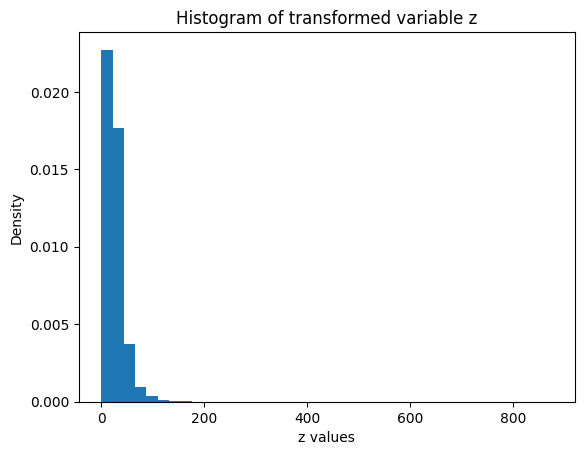

In [21]:
# ---------------- STEP 11: Plot histogram of transformed data ----------------
plt.hist(z, bins=40, density=True)
plt.title("Histogram of transformed variable z")
plt.xlabel("z values")
plt.ylabel("Density")
plt.show()

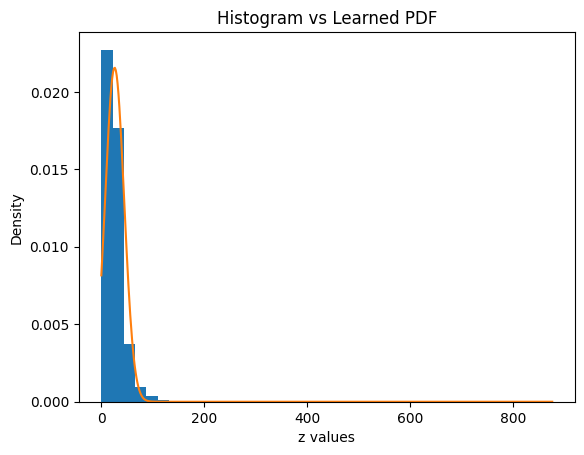

In [22]:
# ---------------- STEP 12: Plot learned PDF curve ----------------
# Generate smooth x values for curve

x_vals = np.linspace(min(z), max(z), 500)

# Gaussian PDF equation
pdf = c * np.exp(-lam * (x_vals - mu)**2)

# Plot histogram + PDF curve together
plt.hist(z, bins=40, density=True)
plt.plot(x_vals, pdf)
plt.title("Histogram vs Learned PDF")
plt.xlabel("z values")
plt.ylabel("Density")
plt.show()